<a id="Setup"></a>
## 1. Setup and Environment

This notebook requires **PhysicsNeMo** and a GPU. 

---

The easiest way to get started is using the official NVIDIA PhysicsNeMo container from NGC.

**1. Pull the container:**
```bash
docker pull nvcr.io/nvidia/physicsnemo/physicsnemo:25.06
```

**2. Run the container:**
```bash
docker run --gpus all \
    --shm-size=1g \
    --ulimit memlock=-1 \
    --ulimit stack=67108864 \
    -v $(pwd):/root \
    -v path/to/data/:/data \
    -v path/to/output/:/output \
    -p 8888:8888 \
    -p 6006:6006 \
    --rm -it nvcr.io/nvidia/physicsnemo/physicsnemo:25.06 bash
```

**3. Install dependencies inside the container:**

Once inside the container, use `uv` (a fast Python package manager) to install PhysicsNeMo with StormCast dependencies and Earth2Studio for data access:

```bash
# Install uv if not already available
pip install uv

# Create venv with uv
cd /root && uv init --python=3.12

# Install PhysicsNeMo from source with model extras (includes dependencies for StormCast)
uv add "nvidia-physicsnemo" --upgrade

# Install Earth2Studio for HRRR/ERA5 data access
uv add "earth2studio @ git+https://github.com/NVIDIA/earth2studio.git@0.12.1" --extra sfno

# Install additional training dependencies
uv add -r x-fx-117-v1/task1/requirements.txt
```

> **Why uv?** The `uv` package manager handles complex dependency resolution much faster than pip and works better with packages that have URL-based dependencies. Using `uv init` creates a project with a `.venv`; `uv run` ensures commands (including kernel registration) use that environment.

**4. Launch Jupyter (optional):**
```bash
# Install ipykernel
uv add ipykernel

# Register the kernel (uv run uses the project's .venv so Jupyter sees the right env)
uv run python -m ipykernel install --user --name=physicsnemo --display-name="PhysicsNeMo"

# Launch Jupyter
jupyter lab --ip=0.0.0.0 --port=8888 --no-browser --allow-root
```
<div class="alert alert-warning">
<strong>Important:</strong> Make sure to activate the PhysicsNeMo kernel.
</div>

---

### Verify Installation

Run the cell below to verify PhysicsNeMo is installed correctly:

In [1]:
# Verify PhysicsNeMo installation
try:
    import physicsnemo
    print(f"✅ PhysicsNeMo version: {physicsnemo.__version__}")
except ImportError:
    print("❌ PhysicsNeMo not found. Please follow the installation instructions above.")

# Check GPU availability
import torch
if torch.cuda.is_available():
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA version: {torch.version.cuda}")
else:
    print("⚠️  No GPU detected. Training will be slow.")

/opt/venv/lib/python3.12/site-packages/physicsnemo/utils/filesystem.py:76: SyntaxWarning: invalid escape sequence '\w'
  pattern = re.compile(f"{suffix}[\w-]+(/[\w-]+)?/[\w-]+@[A-Za-z0-9.]+/[\w/](.*)")


✅ PhysicsNeMo version: 1.3.0
✅ GPU available: NVIDIA RTX 6000 Ada Generation
   CUDA version: 12.8


In [2]:
# Setup environment and imports
import os
import sys
import shutil
import tempfile
from pathlib import Path

import numpy as np
import xarray as xr
import yaml
import zarr
import matplotlib.pyplot as plt

# Base paths
ROOT = Path("/root/").resolve()
sys.path.insert(0, str(ROOT / "x-fx-117-v1/task1"))

DATA_DIR = "/data"
OUTPUT_DIR = "/output"
CONFIG_DIR = ROOT / "x-fx-117-v1/task1/config"

# Set plotting style (optional)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    plt.switch_backend("Agg")

plt.rcParams["figure.figsize"] = [12, 8]
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

<a id="Introduction"></a>
## 2. Regional weather modeling with diffusion models


### Motivation


Many applications require **high-resolution, region-specific weather information** that global models cannot directly provide:
- Convection-permitting detail (1–3 km): storms, extreme precipitation, wind ramps
- Strong influence of local physics and terrain (orography, coastlines, land–sea contrasts)
- Limited-area domains and short lead times tailored to operational needs


Traditionally, this is addressed using **nested regional models (LAMs / CAMs)** driven by coarse global forcing. In this workshop, we explore a data-driven alternative: **diffusion-based regional weather modeling**, implemented using the **NVIDIA PhysicsNeMo** library.

Recent results in weather diffusion modeling suggest a shift from **regression + diffusion** (e.g., StormCast [2], CorrDiff [1]) toward **diffusion-only** approaches (e.g., Climate in a Bottle [3], Stormscope [4]).

---


<a id="Diffusion-Regional-Modeling"></a>
### Diffusion models for regional modeling


Diffusion models learn **conditional probability distributions** over high-resolution atmospheric states. This makes them well suited for regional modeling, where fine-scale structure must be consistent with both large-scale forcing and local geography.


We consider the generic formulation:
$$
p(M_{t+1} \mid M_t, S_{t+1}, s)
$$
where:
- $ M_t $ is the high-resolution regional state at time $ t $
- $ S_t $ is a coarse-resolution background (e.g., global reanalysis or model output)
- $ s $ are static invariants (e.g., orography, land/sea mask)


Sampling from this distribution produces physically plausible high-resolution realizations conditioned on large-scale context.


---


<a id="Problem-Setting"></a>
### Problem setting


In this notebook, we train a **diffusion-only regional model** that directly predicts the next high-resolution state $M_{t+1}$.


The trained model can be used for:
- **One-step emulation** of convection-allowing model updates
- **Autoregressive rollout** for short-range regional forecasting
- **Conditional downscaling** from coarse to kilometer-scale resolution


<div class="alert alert-info">
<strong>Key characteristics:</strong>
<ul>
<li>Conditional generation using previous HR state, coarse background, and static fields</li>
<li>Explicit uncertainty representation via diffusion sampling</li>
<li>Compatibility with nested-model (parent → regional) workflows</li>
</ul>
</div>


---


<a id="Model-Overview"></a>
### Model overview


As a concrete instantiation of this regional diffusion framework, we use a **StormCast-style diffusion model**. StormCast was designed for **kilometer-scale convection-allowing model (CAM) emulation** and serves here as a practical template for regional diffusion modeling.

<div align="left">
<img src="imgs/sciadv.adv0423-f9.jpg" alt="StormCast Architecture" width="800">
<p><em>Figure: StormCast [1] architecture overview. The model uses a two-stage approach with a regression network followed by a diffusion model to generate high-resolution weather predictions from coarse inputs.</em></p>
</div>

In this workshop, we train a **diffusion-only** variant that directly predicts the next high-resolution state, without a separate regression network.


---


<a id="Architecture-Details"></a>
### Architecture details


The model uses an EDM-style diffusion U-Net with:
- residual blocks and skip connections
- attention at selected spatial resolutions
- multi-source conditioning (HR state, LR background, static invariants)

<div align="left">
<h4>U-Net Architecture</h4>

```
                              ┌─────────────────┐
                              │   Bottleneck    │
                              │   (attention)   │
                              └────────┬────────┘
                                       │
           ┌───────────────────────────┼───────────────────────────┐
           │                           │                           │
           ▼                           │                           ▼
    ┌─────────────┐                    │                    ┌─────────────┐
    │  Encoder    │                    │                    │  Decoder    │
    │  Block 3    │════════════════════╪════════════════════│  Block 3    │
    │  (256 ch)   │     skip connection│                    │  (256 ch)   │
    └──────┬──────┘                    │                    └──────▲──────┘
           │ ↓ downsample              │              upsample ↑   │
    ┌──────▼──────┐                    │                    ┌──────┴──────┐
    │  Encoder    │                    │                    │  Decoder    │
    │  Block 2    │════════════════════╪════════════════════│  Block 2    │
    │  (256 ch)   │     skip connection│                    │  (256 ch)   │
    └──────┬──────┘                    │                    └──────▲──────┘
           │ ↓ downsample              │              upsample ↑   │
    ┌──────▼──────┐                    │                    ┌──────┴──────┐
    │  Encoder    │                    │                    │  Decoder    │
    │  Block 1    │════════════════════╪════════════════════│  Block 1    │
    │  (256 ch)   │     skip connection│                    │  (256 ch)   │
    └──────┬──────┘                    │                    └──────▲──────┘
           │ ↓ downsample              │              upsample ↑   │
    ┌──────▼──────┐                    │                    ┌──────┴──────┐
    │  Encoder    │                                         │  Decoder    │
    │  Block 0    │═════════════════════════════════════════│  Block 0    │
    │  (128 ch)   │              skip connection            │  (128 ch)   │
    └──────┬──────┘                                         └──────▲──────┘
           │                                                       │
    ┌──────▼──────┐                                         ┌──────┴──────┐
    │ Input Conv  │                                         │ Output Conv │
    └──────┬──────┘                                         └──────▲──────┘
           │                                                       │
    ┌──────▼──────┐                                         ┌──────┴──────┐
    │    Input    │                                         │   Output    │
    │ (C_in,H,W)  │                                         │ (C_out,H,W) │
    └─────────────┘                                         └─────────────┘

    Conditioning: noise level σ + class labels → embedding → injected at each block
```

<p><em>Figure: U-Net architecture used in diffusion models. The encoder progressively downsamples while increasing channels, the decoder upsamples with skip connections from the encoder. Attention is applied at the bottleneck and optionally at specific resolutions.</em></p>
</div>

Architecture and hyperparameters are defined in:
- `config/model/stormcast_mini.yaml` (mini)
- `config/model/stormcast.yaml` (full)


Diffusion settings are enabled via the top-level configuration created below.


**References:**
- [1] Pathak, J., et al. (2026). *Kilometer-scale convection allowing model emulation using generative diffusion modeling*. https://www.science.org/doi/10.1126/sciadv.adv0423
- [2] Mardani, M., et al. (2025). *Residual corrective diffusion modeling for km-scale atmospheric downscaling*. https://www.nature.com/articles/s43247-025-02042-5
- [3] Brenowitz, N., et al. (2025). *Climate in a Bottle: Towards a Generative Foundation Model for the Kilometer-Scale Global Atmosphere* (2026). https://arxiv.org/abs/2601.17268
- [4] Pathak, J., et al. (2026). *Learning Accurate Storm-Scale Evolution from Observations*. https://arxiv.org/abs/2601.17268


# <a id="Visualization"></a>
### Data Visualization (Optional)

StormCast datasets are typically stored in Zarr and may be large. Visualization is optional and depends on your local data setup. If you have a small subset available, you can load a single timestep and plot fields with `matplotlib`.

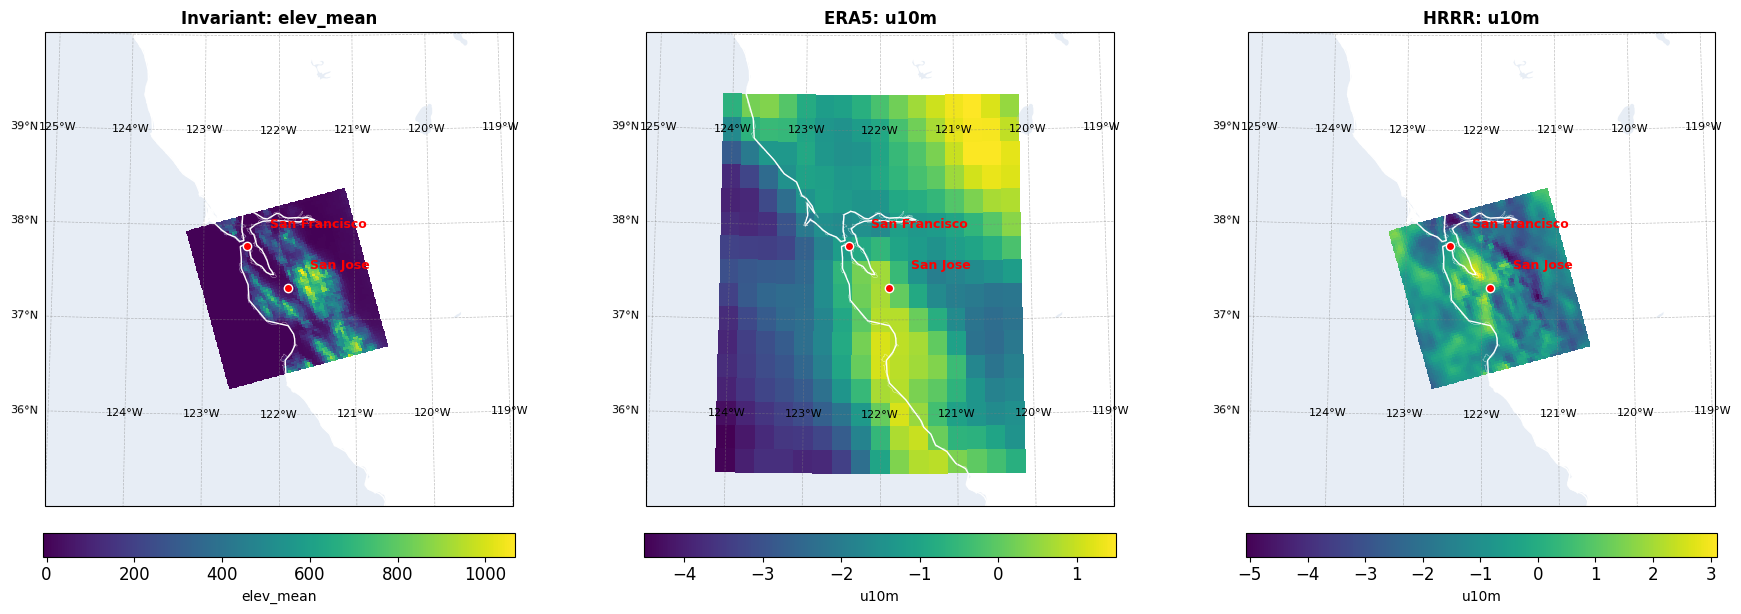

In [3]:
# Example (pseudo‑code) for plotting a single field
from scripts.plots import plot_era5_hrrr
fig = plot_era5_hrrr(
    idx=0,
    era5_path=f"{DATA_DIR}/era5/train/2024.zarr",
    hrrr_path=f"{DATA_DIR}/hrrr/train/2024.zarr",
    invariants_path=f"{DATA_DIR}/hrrr/invariants.zarr",
    extent=(-125, -119, 35, 40),
    show_cities=True,
    inv_name="elev_mean",
    era5_name="u10m",
    hrrr_name="u10m",
)

## 3. Building a StormCast-compatible dataset
All spatial fields must share the same horizontal grid:


- Background: `(C_bg, H, W)`
- State (input and target): `(C_state, H, W)`
- Invariants (if present): `(C_inv, H, W)`


The height and width `(H, W)` are defined by the dataset and reported via `image_shape()`.

---

<a id="Dataset-Grid-Interpolation"></a>
### Grid interpolation: Mapping coarse to fine resolution

A key challenge in regional modeling is that the **background field** (e.g., ERA5 at ~25km) and the **target state field** (e.g., HRRR at ~3km) live on different grids:

| Field | Resolution | Grid Type | Coordinates |
|-------|------------|-----------|-------------|
| ERA5 (background) | ~25 km | Regular lat/lon | 1D `lat`, `lon` arrays |
| HRRR (state) | ~3 km | Lambert Conformal | 2D `lat(y,x)`, `lon(y,x)` arrays |

Since the model expects all inputs to have the same spatial shape `(H, W)`, we **interpolate the coarse ERA5 data onto the high-resolution HRRR grid** at each timestep.

**Interpolation approach:**

We use **Nearest Neighbor interpolation** for efficiency:

1. **Build a KDTree** from ERA5's (lat, lon) coordinates
2. **Query** the tree for each HRRR grid point to find the nearest ERA5 cell
3. **Index** the ERA5 data using the precomputed indices

```python
from scipy.spatial import cKDTree
import numpy as np

# Build tree from ERA5 coordinates (done once)
era5_lon_2d, era5_lat_2d = np.meshgrid(era5_lon, era5_lat)
era5_points = np.column_stack([era5_lat_2d.ravel(), era5_lon_2d.ravel()])
knn_tree = cKDTree(era5_points)

# Find nearest ERA5 point for each HRRR point (done once)
hrrr_points = np.column_stack([hrrr_lat.ravel(), hrrr_lon.ravel()])
_, knn_indices = knn_tree.query(hrrr_points, k=1)

# Interpolate ERA5 to HRRR grid (done per sample)
def interp_era5_to_hrrr(era5_data):
    # era5_data: (C, lat, lon)
    era5_flat = era5_data.reshape(era5_data.shape[0], -1)
    return era5_flat[:, knn_indices].reshape(era5_data.shape[0], *hrrr_lat.shape)
```

<div class="alert alert-warning">
<strong>Why nearest-neighbor instead of bilinear interpolation?</strong>
<ul>
<li><strong>Speed:</strong> Nearest-neighbor with precomputed indices is a simple array indexing operation</li>
<li><strong>Simplicity:</strong> No need to handle edge cases or curvilinear grid math</li>
<li><strong>Sufficient accuracy:</strong> For ~8x resolution difference, nearest-neighbor introduces minimal error</li>
</ul>
For higher accuracy needs, consider bilinear or conservative remapping (e.g., using <code>xesmf</code>).
</div>

---

<a id="Dataset-Zarr-Structure"></a>
### Zarr data structure

We are storing training and validation data using **Zarr archives**. Below is the current data directory and array structure:

```
data/
├── era5/                           # Low-resolution background (ERA5)
│   ├── train/
│   │   └── 2024.zarr/
│   │       ├── fields/             # Main data array
│   │       │   └── (time, channel, lat, lon)
│   │       ├── time/               # Timestamps
│   │       │   └── (time,)
│   │       ├── lat/                # Latitude coordinates
│   │       │   └── (lat,)
│   │       └── lon/                # Longitude coordinates
│   │           └── (lon,)
│   └── valid/
│       └── 2024.zarr/
│
├── hrrr/                           # High-resolution state (HRRR)
│   ├── train/
│   │   └── 2024.zarr/
│   │       ├── fields/             # Main data array
│   │       │   └── (time, channel, y, x)
│   │       ├── time/               # Timestamps (aligned with ERA5)
│   │       │   └── (time,)
│   │       ├── lat/                # 2D latitude grid
│   │       │   └── (y, x)
│   │       └── lon/                # 2D longitude grid
│   │           └── (y, x)
│   ├── valid/
│   │   └── 2024.zarr/
│   │
│   └── invariants.zarr/            # Static fields (terrain, land-sea mask)
│       ├── fields/
│       │   └── (channel, y, x)
│       ├── lat/
│       │   └── (y, x)
│       └── lon/
│           └── (y, x)
│
└── stats/                          # Normalization statistics
    ├── era5_mean.npy               # (C_bg,)
    ├── era5_std.npy                # (C_bg,)
    ├── hrrr_mean.npy               # (C_state,)
    └── hrrr_std.npy                # (C_state,)
```

<div class="alert alert-info">
<strong>Key design considerations:</strong>
<ul>
<li><strong>Temporal alignment:</strong> ERA5 and HRRR timestamps are aligned (same time indices refer to same valid times)</li>
<li><strong>Spatial grids:</strong> HRRR uses a Lambert Conformal projection (2D lat/lon), ERA5 uses regular lat/lon (1D)</li>
<li><strong>Chunking:</strong> Chunk along time dimension for efficient random access: <code>chunks=(1, C, H, W)</code></li>
<li><strong>Compression:</strong> Use <code>blosc</code> or <code>zstd</code> for good compression ratios</li>
</ul>
</div>

**Example: Opening a Zarr archive**
```python
import zarr

# Open HRRR data
hrrr = zarr.open("data/hrrr/train/2024.zarr", mode="r")
fields = hrrr["fields"]  # shape: (T, C, H, W)
print(f"Shape: {fields.shape}, Chunks: {fields.chunks}")

# Access a single timestep (efficient due to chunking)
sample = fields[100]  # shape: (C, H, W)
```

---


<a id="Dataset-Required-Methods"></a>
### Required methods


A custom dataset must inherit from `StormCastDataset` and implement the following abstract methods:


```python
class MyDataset(StormCastDataset):
def background_channels(self) -> list[str]: ...
def state_channels(self) -> list[str]: ...
def image_shape(self) -> tuple[int, int]: ...
```


In addition, the dataset must implement the standard PyTorch dataset methods:


```python
def __init__(self, params, train: bool): ...
def __len__(self) -> int: ...
def __getitem__(self, idx: int) -> dict: ...
```


The channel lists returned by `background_channels()` and `state_channels()` define the **channel ordering** expected by the model and must match the data returned by `__getitem__`.


---


<a id="Dataset-Invariants"></a>
### Static invariants


If static fields are used, they must be returned by overriding:


```python
def get_invariants(self) -> np.ndarray | None:
return invariants # shape: (C_inv, H, W)
```


If no invariants are needed, the default implementation returning `None` is sufficient.


---


<a id="Dataset-Normalization"></a>
### Normalization


Datasets are responsible for handling normalization and denormalization by overriding:


```python
def normalize_background(self, x): ...
def denormalize_background(self, x): ...


def normalize_state(self, x): ...
def denormalize_state(self, x): ...
```


Typical choices include per-channel zero-mean/unit-variance normalization using statistics computed offline.


---


<a id="Dataset-Metadata"></a>
### Optional spatial metadata


For diagnostics and output generation, datasets may optionally provide latitude and longitude grids:


```python
def latitude(self) -> np.ndarray: ...
def longitude(self) -> np.ndarray: ...
```


If not needed, the default implementations return arrays filled with `NaN`.


---


<a id="Dataset-Examples"></a>
### Reference implementations


Concrete examples of StormCast-compatible datasets include:


- `data_loader_hrrr_era5.py`: full HRRR–ERA5 regional dataset for the original StormCast training.


These implementations are the best reference for handling multi-source I/O, normalization, and temporal indexing.

---

## Tasks: Data Understanding

Try these exercises to explore the dataset structure.

---

**Task 1: Explore the Data**

Open the HRRR and ERA5 Zarr files and answer these questions:

- What is the spatial shape (H, W) of each dataset?
- How many timesteps are available?
- What variables/channels are included?


<details>
<summary>Click to see the solution</summary>

```python
import xarray as xr

ds_hrrr = xr.open_zarr(f"{DATA_DIR}/hrrr/train/2024.zarr")
ds_era5 = xr.open_zarr(f"{DATA_DIR}/era5/train/2024.zarr")

print("HRRR dimensions:", ds_hrrr.dims)
print("ERA5 dimensions:", ds_era5.dims)
print("\nHRRR channels:", list(ds_hrrr.channel.values))
print("ERA5 channels:", list(ds_era5.channel.values))
print("\nHRRR coordinates:", list(ds_hrrr.coords))
print("ERA5 coordinates:", list(ds_era5.coords))
# Show shape without loading data
print("\nHRRR shape:", ds_hrrr['HRRR'].shape)
print("ERA5 shape:", ds_era5['data'].shape)
```

In [4]:
# Your code here

**Task 2: Visualize a Sample**

Load and visualize a single timestep:

<details>
<summary>Click to see the solution</summary>

```python
idx = 100
hrrr_sample = ds_hrrr.HRRR.isel(time=idx)
era5_sample = ds_era5.data.isel(time=idx)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(hrrr_sample[0])
axes[0].set_title("HRRR (3km)")
axes[1].imshow(era5_sample[0])
axes[1].set_title("ERA5 (25km)")
plt.show()
```

In [5]:
# Your code here

**Task 3: Visualize the Grid Difference**

Plot both grids overlaid to see the resolution difference:
What is the approximate ratio of grid points?

<details>
<summary>Click to see the solution</summary>

```python
hrrr_lat = ds_hrrr.latitude.values
hrrr_lon = ds_hrrr.longitude.values
era5_lat = ds_era5.latitude.values
era5_lon = ds_era5.longitude.values

plt.figure(figsize=(10, 8))
plt.scatter(hrrr_lon[::10, ::10], hrrr_lat[::10, ::10], s=10, alpha=1, label='HRRR')
era5_lon_2d, era5_lat_2d = np.meshgrid(era5_lon, era5_lat)
plt.scatter(era5_lon_2d, era5_lat_2d, s=20, c='red', marker='x', alpha=.7, label='ERA5')
plt.legend()
plt.title('Grid Comparison')
```

In [6]:
# Your code here

**Task 4: Check Normalization Statistics**

Print Mean and Standard Deviation for the HRRR variables.

<details>
<summary>Click to see the solution</summary>

```python
hrrr_mean = np.load(f"{DATA_DIR}/hrrr/stats/means.npy")
hrrr_std = np.load(f"{DATA_DIR}/hrrr/stats/stds.npy")

print("Shape:", hrrr_mean.shape)
print("Means:", hrrr_mean[:5])
print("Stds:", hrrr_std[:5])

# Any zero stds would cause issues
if np.any(hrrr_std == 0):
    print("WARNING: Zero std detected!")
```

In [7]:
# Your code here

<a id="Configuration"></a>
## 4. Configuration

<a id="Hydra-Setup"></a>
### Hydra Configuration

This example uses **Hydra** for configuration management. Configs are modular and composed from subdirectories:

- **dataset/**: data paths, variables, invariants
- **model/**: model architecture (regression + diffusion settings)
- **training/**: optimizer, scheduler, batch size, checkpointing
- **sampler/**: diffusion sampler parameters (sigma bounds, num_steps)
- **hydra/**: output directory templates

<div class="alert alert-info">
<strong>Configuration Structure:</strong>
<ul>
<li><strong>Dataset config</strong> — You customize this for your data (paths, channels, invariants)</li>
<li><strong>Model & Training defaults</strong> — Sensible defaults that rarely need changes</li>
<li><strong>Top-level config</strong> — Composes everything and exposes key parameters (batch size, lr, steps)</li>
</ul>
</div>

### Dataset Configuration

Unlike the model and training configs, the **dataset config must be customized** for your data. Update the paths and channels below to match your setup:

| Parameter | Description |
|-----------|-------------|
| `era5_path`, `hrrr_path` | Paths to your ERA5/HRRR Zarr archives |
| `era5_stats_path`, `hrrr_stats_path` | Directories with `means.npy` and `stds.npy` |
| `era5_channels`, `hrrr_channels` | Variables to use (`"all"` or list of names) |
| `invariants_path`, `invariants` | Static fields (terrain, land-sea mask) |
| `dt` | Lead time in hours |

<div class="alert alert-warning">
<strong>Important:</strong> Make sure the paths point to your actual data files. The example below uses the mini dataset structure.
</div>

In [8]:
# Create custom config files for StormCast mini (diffusion‑only)
from pathlib import Path

custom_dataset = {
    "name": "data_loader_hrrr_era5_mini.HrrrEra5DatasetMini",
    # Zarr dataset paths
    "era5_path": f"{DATA_DIR}/era5/train/2024.zarr",
    "hrrr_path": f"{DATA_DIR}/hrrr/train/2024.zarr",
    "invariants_path": f"{DATA_DIR}/hrrr/invariants.zarr",
    # Stats paths (directories containing means.npy and stds.npy)
    "era5_stats_path": f"{DATA_DIR}/era5/stats",
    "hrrr_stats_path": f"{DATA_DIR}/hrrr/stats",
    # Temporal
    "dt": 1,
    # Channel selection
    "era5_channels": "all",
    "hrrr_channels": ["u10m", "v10m", "t2m"],
    # Invariants
    "invariants": ["lsm_mean", "elev_mean", "elev_std"],
}

with open(f"{CONFIG_DIR}/dataset/hrrr_era5_mini.yaml", "w") as f:
    yaml.dump(custom_dataset, f, default_flow_style=False, sort_keys=False)
print("✅ Wrote custom configs:")
print(f"- {CONFIG_DIR}/dataset/hrrr_era5_mini.yaml")

✅ Wrote custom configs:
- /root/x-fx-117-v1/task1/config/dataset/hrrr_era5_mini.yaml


<a id="Data-Loading"></a>
### Dataset configuration and loading


Datasets are typically instantiated via **Hydra configuration files** under `config/dataset/`, rather than created directly in the notebook.
The training recipe resolves the dataset class, parameters, and train/validation split automatically from the configuration.

In [9]:
# Example: loading the dataset via Hydra config (optional)
from omegaconf import OmegaConf
from datasets.data_loader_hrrr_era5_mini import HrrrEra5DatasetMini

cfg = OmegaConf.load(f"{CONFIG_DIR}/dataset/hrrr_era5_mini.yaml")
dataset = HrrrEra5DatasetMini(cfg, train=True)
sample = dataset[0]
print(sample["background"].shape, sample["state"][0].shape, sample["state"][1].shape)

torch.Size([26, 64, 64]) torch.Size([3, 64, 64]) torch.Size([3, 64, 64])


### Model Default

The model config defines the diffusion-only architecture. These defaults work well for most cases.

<details>
<summary>Click to see what's configured</summary>

- `model_name`: "diffusion" (no regression network)
- `diffusion_conditions`: state, background, and invariant inputs
- `hyperparameters`: channel multipliers, number of blocks, attention settings

</details>

In [10]:
# Create custom config files for StormCast mini (diffusion‑only)
from pathlib import Path

custom_model = {
    "model_name": "diffusion",
    "regression_weights": None,
    "regression_conditions": [],
    "diffusion_conditions": ["state", "background", "invariant"],
    "spatial_pos_embed": False,
    "hyperparameters": {
        "channel_mult": [1, 2, 2],
        "num_blocks": 2,
        "model_channels": 64,
        "checkpoint_level": 0,
        "attn_resolutions": [],
    },
}

with open(f"{CONFIG_DIR}/model/stormcast_mini.yaml", "w") as f:
    yaml.dump(custom_model, f, default_flow_style=False, sort_keys=False)
print("✅ Wrote custom configs:")
print(f"- {CONFIG_DIR}/model/stormcast_mini.yaml")

✅ Wrote custom configs:
- /root/x-fx-117-v1/task1/config/model/stormcast_mini.yaml


### Training Configuration Reference

The training config contains optimizer, loss, scheduler, and performance settings. The defaults below work well for the mini model — **adjust them in the top-level config** rather than editing this file directly.

The training default config (`config/training/stormcast_mini_training.yaml`) contains all training settings.
Below is a reference of the available parameters — **override these in the top-level config**, not here.

#### Output & Identity
| Parameter | Default | Description |
|-----------|---------|-------------|
| `outdir` | `"rundir"` | Root directory for outputs |
| `experiment_name` | `"stormcast_mini"` | Name for grouping runs |
| `run_id` | `"0"` | Unique identifier for this run |

#### Optimization
| Parameter | Default | Description |
|-----------|---------|-------------|
| `batch_size` | `64` | Total batch size across all GPUs |
| `lr` | `4e-4` | Initial learning rate |
| `total_train_steps` | `40000` | Total training iterations |
| `lr_rampup_steps` | `1000` | Linear warmup steps |
| `clip_grad_norm` | `-1` | Gradient clipping (-1 = disabled) |

#### Logging & Checkpointing
| Parameter | Default | Description |
|-----------|---------|-------------|
| `print_progress_freq` | `100` | Steps between progress logs |
| `checkpoint_freq` | `1000` | Steps between checkpoints |
| `validation_freq` | `1000` | Steps between validation |
| `log_to_tensorboard` | `True` | Enable TensorBoard logging |
| `log_to_wandb` | `False` | Enable Weights & Biases |

#### Loss (EDM)
| Parameter | Default | Description |
|-----------|---------|-------------|
| `loss.type` | `"edm"` | Loss type (EDM diffusion) |
| `loss.sigma_distribution` | `"loguniform"` | Noise schedule distribution |
| `loss.sigma_min` | `0.001` | Minimum noise level |
| `loss.sigma_max` | `800` | Maximum noise level |

#### Performance
| Parameter | Default | Description |
|-----------|---------|-------------|
| `perf.fp_optimizations` | `"fp32"` | Precision: `"fp32"`, `"amp-fp16"`, `"amp-bf16"` |
| `perf.allow_tf32` | `True` | Enable TF32 for faster matmul |
| `perf.torch_compile` | `False` | Use torch.compile |

<div class="alert alert-info">
<strong>Tip:</strong> To change any of these, add them to the <code>training:</code> section in the top-level config below.
</div>

---

### Your Experiment Config

The top-level config composes the defaults above and lets you **override the key parameters** for your experiment:

| Parameter | Description |
|-----------|-------------|
| `training.batch_size` | Total batch size across all GPUs |
| `training.lr` | Initial learning rate |
| `training.total_train_steps` | Total training iterations |
| `training.experiment_name` | Name for organizing outputs |
| `validation.era5_path` / `hrrr_path` | Paths to validation data |

<div class="alert alert-success">
<strong>Tip:</strong> Start with the defaults and only change what you need. The most common customizations are batch size, learning rate, and training steps.
</div>

In [11]:
# ============================================================
# Key parameters to customize for your experiment
# ============================================================

# Experiment identity
EXPERIMENT_NAME = "stormcast"
RUN_ID = "mini"

# Training hyperparameters (most commonly adjusted)
BATCH_SIZE = 64          # Total batch size across GPUs
LEARNING_RATE = 1e-3     # Initial learning rate
TOTAL_STEPS = 20000      # Total training iterations

# Optional: Adjust these for faster iteration or debugging
CHECKPOINT_FREQ = 500   # How often to save checkpoints
VALIDATION_FREQ = 500   # How often to validate

# ============================================================

custom_top = {
    # Compose from default configs
    "defaults": [
        "dataset/hrrr_era5_mini",
        "model/stormcast_mini",
        "training/default",
        "sampler/edm_deterministic",
        "hydra/default",
        "_self_",
    ],
    # Override training parameters
    "training": {
        "outdir": "/output/rundir",
        "experiment_name": EXPERIMENT_NAME,
        "run_id": RUN_ID,
        "batch_size": BATCH_SIZE,
        "lr": LEARNING_RATE,
        "total_train_steps": TOTAL_STEPS,
        "lr_rampup_steps": 500,
        "log_to_tensorboard": True,
        "checkpoint_freq": CHECKPOINT_FREQ,
        "validation_freq": VALIDATION_FREQ,
        "validation_plot_variables": ["u10m", "v10m", "t2m"],
        "validation_plot_background_variables": ["u10m", "v10m", "t2m"],
        "perf": {
            "fp_optimizations": "amp-bf16", # Floating point mode: "fp32", "amp-fp16", "amp-bf16"
            "use_apex_gn": True, # Use Apex GroupNorm (enables channels_last memory format)
        },
        "loss": {
            "type": "edm",
            "sigma_distribution": "loguniform",
            "sigma_min": 0.001,
            "sigma_max": 800,
            "sigma_data": .5,
        },
    },
    # Validation data paths
    "validation": {
        "era5_path": f"{DATA_DIR}/era5/val/2025.zarr",
        "hrrr_path": f"{DATA_DIR}/hrrr/val/2025.zarr",
    },
}

with open(f"{CONFIG_DIR}/stormcast_mini_diffusion_only.yaml", "w") as f:
    yaml.dump(custom_top, f, default_flow_style=False, sort_keys=False)

print(f"✅ Wrote top-level config: {CONFIG_DIR}/stormcast_mini_diffusion_only.yaml")
print(f"""\n📋 Training settings:
   • Experiment: {EXPERIMENT_NAME}/{RUN_ID}
   • Batch size: {BATCH_SIZE}
   • Learning rate: {LEARNING_RATE}
   • Total steps: {TOTAL_STEPS}
""")

✅ Wrote top-level config: /root/x-fx-117-v1/task1/config/stormcast_mini_diffusion_only.yaml

📋 Training settings:
   • Experiment: stormcast/mini
   • Batch size: 64
   • Learning rate: 0.001
   • Total steps: 20000



---

## Tasks: Performance Profiling

Experiment with configuration options and observe their impact on performance. The training logs automatically report **GPU memory**, **CPU memory**, and **seconds per step** - just read the values from the output.

Run short training runs (50-100 steps) with `training.total_train_steps=50` and compare the logged metrics.

---

**Task 5: Baseline Performance**

Run training with the default configuration and record the metrics from the logs:

| Metric | Value |
|--------|-------|
| GPU Memory (GB) | |
| CPU Memory (GB) | |
| Time/Step (s) | |

---

**Task 6: Batch Size vs Memory**

Run training with different batch sizes and record the logged metrics:

| Batch Size | GPU Memory (GB) | Time/Step (s) |
|------------|-----------------|---------------|
| 16         |                 |               |
| 32         |                 |               |
| 128        |                 |               |

Does memory scale linearly with batch size? Why or why not?

---

**Task 7: Mixed Precision (AMP)**

Compare FP32 vs FP16 by changing `training.perf.fp_optimizations`:

| Mode | GPU Memory (GB) | Time/Step (s) |
|------|-----------------|---------------|
| `fp32` | | |
| `amp-fp16` | | |

How much memory is saved? How much faster is each step?

---

**Task 8: Model Size Comparison**

Try different `model_channels` values and compare the logged metrics:

| model_channels | GPU Memory (GB) | Time/Step (s) |
|----------------|-----------------|---------------|
| 64             |                 |               |
| 128 (default)  |                 |               |
| 256            |                 |               |



---

### Training the Diffusion‑Only Model

Use the custom top‑level config generated above:

```bash
python train.py --config-name stormcast_mini_diffusion_only
```

Outputs are written to the `training.rundir` location defined in the config (see `training.outdir`, `training.experiment_name`, `training.run_id`).


In [12]:
# !cd .. && python train.py --config-name stormcast_mini_diffusion_only
# !cd .. && torchrun --nproc-per-node=2 train.py --config-name stormcast_mini_diffusion_only

### Visualizing Training Progress

StormCast can log to TensorBoard and/or Weights & Biases depending on `training.log_to_tensorboard` and `training.log_to_wandb`.

**TensorBoard**
```bash
tensorboard --logdir=<training.rundir>/tensorboard --port=6006 --bind_all
```

If you're running tensorboard remotely, ssh into the server:
```bash
ssh -L 6006:localhost:6006 user@server
```

**Weights & Biases**
Set `training.log_to_wandb: true` and configure `training.wandb_mode` (e.g., `"offline"` or `"online"`).

In [15]:
# !tensorboard --logdir=/output/rundir/stormcast/mini/tensorboard --host 0.0.0.0 --port=6006

### Visualizing Training Samples

During training, StormCast periodically saves validation images showing:
- **Ground truth** (target HRRR fields)
- **Model predictions** (generated samples)
- **Spectral analysis** (power spectrum comparison)

These images are saved to `{rundir}/images/{variable}/` and help monitor whether the model is learning realistic spatial structures.

**Three Visualization Options:**
| Option | Description | Use Case |
|--------|-------------|----------|
| **1. Static Display** | Show multiple samples from a single training step | Quick inspection of current model quality |
| **2. Animated GIF** | Auto-playing animation of the same sample across steps | Presentations, sharing results |
| **3. Interactive Slider** | Manually scrub through training steps | Detailed analysis of when/how model improves |

Creating GIF with 40 frames (steps: [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500, 13000, 13500, 14000, 14500, 15000, 15500, 16000, 16500, 17000, 17500, 18000, 18500, 19000, 19500, 20000])
GIF saved to: /output/rundir/stormcast/mini/progression_t2m_0.gif


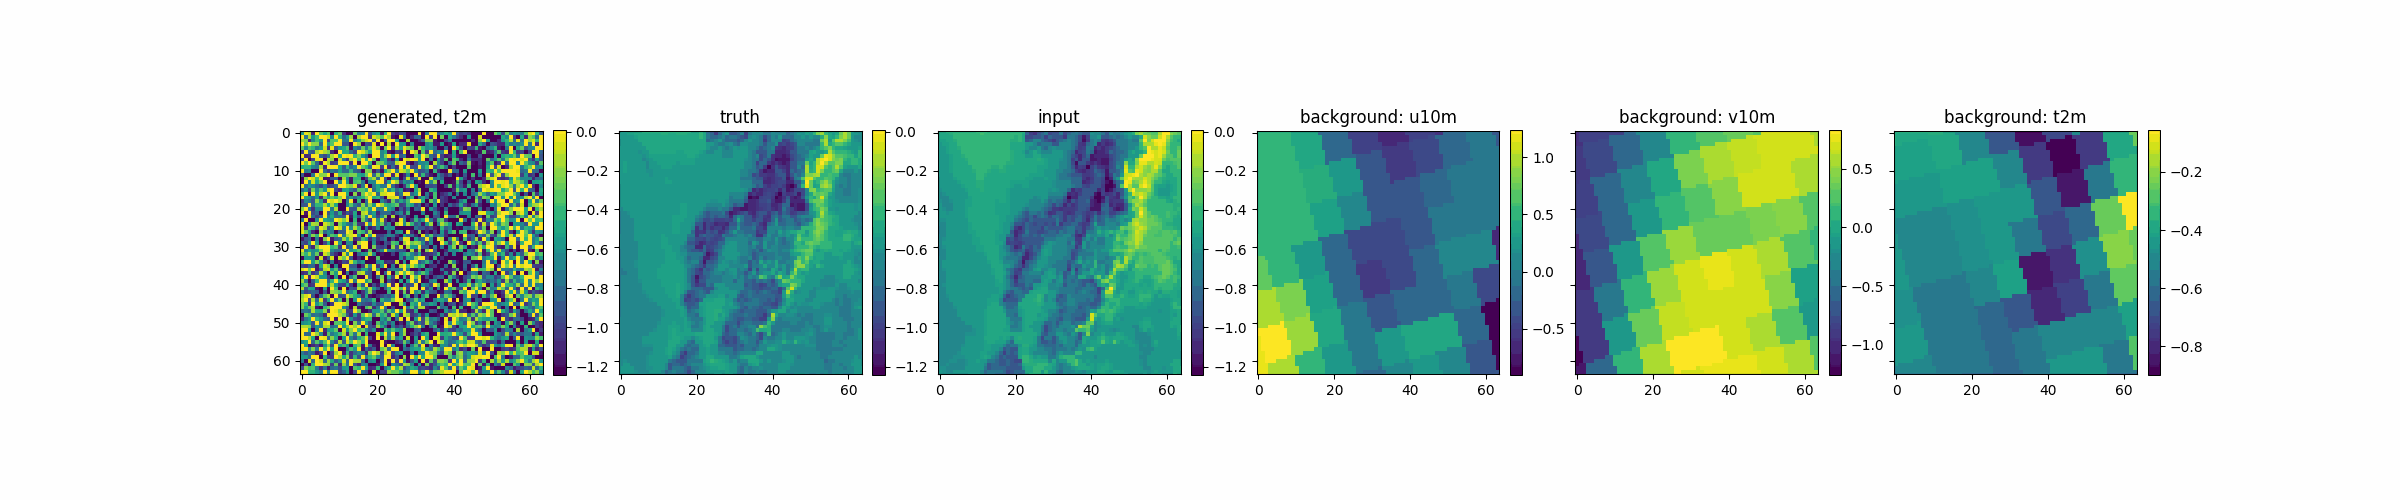

In [16]:
# =============================================================================
# Create an animated GIF showing training progression
# =============================================================================

from scripts.plots import create_training_progression_gif

# Set the run directory for all visualization functions
vis_dir = f"/output/rundir/{EXPERIMENT_NAME}/{RUN_ID}" 

gif_path = create_training_progression_gif(
    rundir=vis_dir,
    variable="t2m",    # Change to "u10m" or "v10m" for other variables
    sample_idx=0,       # Which validation sample to track
    fps=2,              # Frames per second (slower = easier to see changes)
)

# Display the GIF in the notebook
if gif_path and gif_path.exists():
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=str(gif_path)))

### Export the Model to Earth2Studio

After training, you can package your StormCast model for use with [Earth2Studio](https://github.com/NVIDIA/earth2studio), NVIDIA's inference framework for weather/climate AI models.

**What the export creates:**

| File | Description |
|------|-------------|
| `model.yaml` | Sampler configuration (sigma bounds, num_steps, etc.) and invariant metadata |
| `EDMPrecond.0.0.mdlus` | Diffusion model checkpoint (PhysicsNeMo format) |
| `StormCastUNet.0.0.mdlus` | Regression model checkpoint (optional, if training regression+diffusion) |
| `metadata.zarr.zip` | Normalization stats, variable names, invariants, and lat/lon grids |

**Workflow:**
1. First, run the cell below to define the export helper functions
2. Then, update the paths in the final cell to point to your trained checkpoint
3. Run the export cell to create the package

### Run the Export

Update the paths below to match your training run, then execute the cell to create the Earth2Studio package.

In [18]:
# ============================================================================
# Step 1: Set your paths and parameters
# ============================================================================

PACKAGE_DIR = Path(f"/output/model_package")
PACKAGE_DIR.mkdir(parents=True, exist_ok=True)
STEP = 20000
DIFFUSION_CHECKPOINT = f"/output/rundir/{EXPERIMENT_NAME}/{RUN_ID}/checkpoints_diffusion/EDMPrecond.0.{STEP}.mdlus"
REGRESSION_CHECKPOINT = None  # "./checkpoints/StormCastUNet.0.40000.mdlus"

# ============================================================================
# Step 2: Define your variables and sampler settings
# ============================================================================

state_variables = xr.open_dataset(f"{DATA_DIR}/hrrr/train/2024.zarr").channel
conditioning_variables = xr.open_dataset(f"{DATA_DIR}/era5/train/2024.zarr").channel
invariant_names = ["lsm_mean", "elev_mean", "elev_std"]

sampler_args = {
    "num_steps": 18,
    "sigma_min": 0.002,
    "sigma_max": 800.0,
    "rho": 7.0,
    "S_churn": 0,
    "S_min": 0,
    "S_max": float("inf"),
    "S_noise": 1,
}

# ============================================================================
# Step 3: Load or define normalization stats
# ============================================================================

# Option A: Load from files
state_means = np.load(f"{DATA_DIR}/hrrr/stats/means.npy")
state_stds = np.load(f"{DATA_DIR}/hrrr/stats/stds.npy")
conditioning_means = np.load(f"{DATA_DIR}/era5/stats/means.npy")
conditioning_stds = np.load(f"{DATA_DIR}/era5/stats/stds.npy")

# Option B: No normalization (default)
# state_means = np.zeros(len(state_variables), dtype=np.float32)
# state_stds = np.ones(len(state_variables), dtype=np.float32)
# conditioning_means = np.zeros(len(conditioning_variables), dtype=np.float32)
# conditioning_stds = np.ones(len(conditioning_variables), dtype=np.float32)

# ============================================================================
# Step 4: Load or define invariants and coordinates
# ============================================================================

# Option A: Load from zarr
inv_zarr = zarr.open(f"{DATA_DIR}/hrrr/invariants.zarr", mode="r")
invariants = np.stack([inv_zarr[k][:] for k in invariant_names], axis=0)
latitude = inv_zarr["latitude"][:]
longitude = inv_zarr["longitude"][:]

# Option B: Dummy values
# invariants = np.zeros((len(invariant_names), 64, 64), dtype=np.float32)
# latitude = np.zeros((64, 64), dtype=np.float32)
# longitude = np.zeros((64, 64), dtype=np.float32)

# ============================================================================
# Step 5: Create model.yaml
# ============================================================================

model_yaml = {
    "data": {"invariants": invariant_names},
    "sampler_args": sampler_args,
}

with open(PACKAGE_DIR / "model.yaml", "w") as f:
    yaml.dump(model_yaml, f, default_flow_style=False)
print("Created: model.yaml")

# ============================================================================
# Step 6: Copy checkpoints
# ============================================================================

shutil.copy2(DIFFUSION_CHECKPOINT, PACKAGE_DIR / "EDMPrecond.0.0.mdlus")
print(f"Copied: {DIFFUSION_CHECKPOINT} -> EDMPrecond.0.0.mdlus")

# Uncomment if you have a regression checkpoint:
# shutil.copy2(REGRESSION_CHECKPOINT, OUTPUT_DIR / "StormCastUNet.0.0.mdlus")
# print(f"Copied: {REGRESSION_CHECKPOINT} -> StormCastUNet.0.0.mdlus")

# ============================================================================
# Step 7: Create metadata.zarr.zip
# ============================================================================

ds = xr.Dataset()
ds["variable"] = xr.DataArray(np.array(state_variables, dtype=object), dims=["variable"])
ds["conditioning_variable"] = xr.DataArray(np.array(conditioning_variables, dtype=object), dims=["conditioning_variable"])
ds["means"] = xr.DataArray(state_means, dims=["variable"])
ds["stds"] = xr.DataArray(state_stds, dims=["variable"])
ds["conditioning_means"] = xr.DataArray(conditioning_means, dims=["conditioning_variable"])
ds["conditioning_stds"] = xr.DataArray(conditioning_stds, dims=["conditioning_variable"])
ds["invariants"] = xr.DataArray(invariants, dims=["invariant", "y", "x"], coords={"invariant": invariant_names})
ds["latitude"] = xr.DataArray(latitude.astype(np.float32), dims=["y", "x"])
ds["longitude"] = xr.DataArray(longitude.astype(np.float32), dims=["y", "x"])

with tempfile.TemporaryDirectory() as tmpdir:
    zarr_path = Path(tmpdir) / "zarr_contents"
    ds.to_zarr(zarr_path, mode="w", zarr_format=2)
    shutil.make_archive(str(PACKAGE_DIR / "metadata.zarr"), "zip", root_dir=zarr_path)
print("Created: metadata.zarr.zip")
print(f"\n✅ Done! Package at: {PACKAGE_DIR}")

Created: model.yaml
Copied: /output/rundir/stormcast/mini/checkpoints_diffusion/EDMPrecond.0.20000.mdlus -> EDMPrecond.0.0.mdlus
Created: metadata.zarr.zip

✅ Done! Package at: /output/model_package


---

## Challenge Tasks

Ideas for further exploration:

---

**Challenge A: Modify the Dataset**

Try changing the dataset configuration:
- Add or remove channels
- Change the region size
- Use different time ranges for train/validation

---

**Challenge B: Explore Model Architecture**

Experiment with the model configuration:
- Change `model_channels`, `channel_mult`, or `num_blocks`
- Enable/disable attention at different resolutions
- Measure the impact on parameters, memory, and speed

---

**Challenge C: Prepare Your Own Dataset**

Use the provided scripts to create a dataset for a different region or data source:
1. Download data for your region of interest
2. Compute normalization statistics
3. Update the dataset configuration

---

## Summary

In this notebook you learned:

- How regional diffusion models work for weather prediction
- How to structure multi-resolution data (ERA5 + HRRR)
- How interpolation maps coarse background to fine target grid
- How to configure training and measure performance

**Next steps:**
- Try the **inference notebook** for running predictions with the pre-trained model
- Explore ensemble generation and uncertainty quantification
- Apply these techniques to your own datasets